# Mietpreisvorhersage — Wohnungsgröße vs. Miete

**Ziel:** Die Beziehung zwischen der Größe einer Wohnung (in m²) und ihrer Miete (in €) visualisieren — als erster Schritt hin zu einer Mietpreisvorhersage.

---

In [1]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)
print("Imports OK")

Imports OK


## 1. Daten erzeugen

Wir tragen 10 Wohnungen von Hand ein: Wohnungsgröße (m²) und die dazugehörige Miete (€).

In [2]:
# Manuell eingetragene Daten: Wohnungsgröße (m²) → Miete (€)
groesse = np.array([25, 35, 45, 55, 65, 75, 90, 100, 120, 140])
miete   = np.array([380, 480, 560, 600, 700, 760, 900, 940, 1120, 1300])

print(f"{len(groesse)} Wohnungen erfasst")
print(f"Größe: {groesse.min()}–{groesse.max()} m²")
print(f"Miete: {miete.min()}–{miete.max()} €")

10 Wohnungen erfasst
Größe: 25–140 m²
Miete: 380–1300 €


## 2. Daten visualisieren

Ein Scatterplot zeigt, wie die Miete tendenziell mit der Wohnungsgröße steigt.

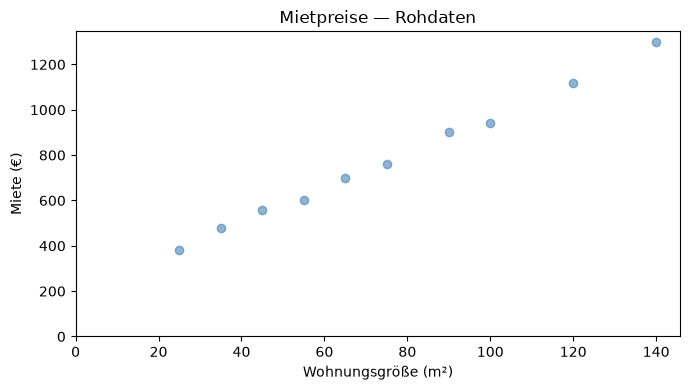

In [3]:
plt.figure(figsize=(7, 4))
plt.scatter(groesse, miete, alpha=0.6, color="steelblue")
plt.xlim(0, None)
plt.ylim(0, None)
plt.xlabel("Wohnungsgröße (m²)")
plt.ylabel("Miete (€)")
plt.title("Mietpreise — Rohdaten")
plt.tight_layout()
plt.show()

## 3. Eine Gerade einzeichnen

Wir berechnen die Gerade `y = w * x + b`, die am besten zu den Daten passt (kleinste Quadrate), um eine erste, einfache Mietpreisvorhersage zu machen.

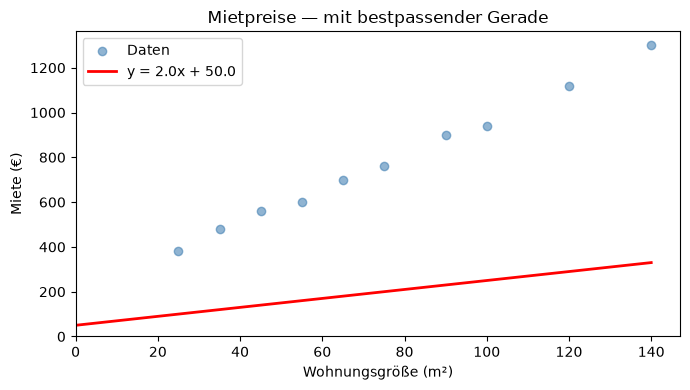

In [4]:
# hier anpassen:
w = 2.0
b = 50.0


x_line = np.linspace(0, groesse.max(), 100)
y_line = w * x_line + b

plt.figure(figsize=(7, 4))
plt.scatter(groesse, miete, alpha=0.6, color="steelblue", label="Daten")
plt.plot(x_line, y_line, color="red", lw=2, label=f"y = {w:.1f}x + {b:.1f}")
plt.xlim(0, None)
plt.ylim(0, None)
plt.xlabel("Wohnungsgröße (m²)")
plt.ylabel("Miete (€)")
plt.title("Mietpreise — mit bestpassender Gerade")
plt.legend()
plt.tight_layout()
plt.show()

## 4. Wie gut passt die Gerade? Loss und Cost Function

Um die geratene Gerade zu bewerten, brauchen wir ein Maß für den Fehler:

- **Loss**: der Fehler *einer einzelnen* Wohnung — Vorhersage vs. tatsächliche Miete, quadriert
- **Cost Function (MSE)**: der *durchschnittliche* Loss über alle Wohnungen (Mean Squared Error) — eine einzige Zahl, die zeigt, wie gut die Gerade insgesamt passt

In [5]:
# Loss: quadrierter Fehler pro einzelner Wohnung
vorhersage = w * groesse + b
loss = (miete - vorhersage) ** 2
loss

array([ 78400., 129600., 176400., 193600., 270400., 313600., 448900.,
       476100., 688900., 940900.])

In [6]:
# Cost Function: Durchschnitt der Loss-Werte über alle Wohnungen (Mean Squared Error)
cost = np.mean(loss)
print(f"Cost (MSE) bei w={w}, b={b}: {cost:.2f}")

Cost (MSE) bei w=2.0, b=50.0: 371680.00
